Loading the dataset

In [0]:
spark_df = spark.read.table("car_sales_cleaned")
print(f"Number of rows: {spark_df.count()}")
print(f"Number of columns: {len(spark_df.columns)}")
spark_df.show(5)

Number of rows: 2500000
Number of columns: 11
+---------+---------+-------------------+----------+------------------+-----------------+----+-----+-------+-----------+-------+
| car_make|car_model|car_production_year|sale_price|   commission_rate|commission_earned|year|month|quarter|day_of_week|car_age|
+---------+---------+-------------------+----------+------------------+-----------------+----+-----+-------+-----------+-------+
|Chevrolet|   Altima|               2017|     41875|0.0910254384830216|          3811.69|2022|    7|      3|          6|      5|
|   Nissan|Silverado|               2016|     31215|0.1341760050408948|           4188.3|2022|   12|      4|          3|      6|
|     Ford|    F-150|               2014|     49207|0.0921627911557312|          4535.05|2022|   12|      4|          2|      8|
|Chevrolet|  Corolla|               2018|     36365|0.1056897705258324|          3843.41|2023|    2|      1|          3|      5|
|    Honda|Silverado|               2020|     26248

Correlation Analysis

Before building the model, a correlation analysis was performed to identify which features have a meaningful relationship with the target variable (sale_price). The Spark DataFrame was converted to Pandas to compute the correlation matrix and visualize it as a heatmap.

Correlation with the target variable (sale_price):
sale_price             1.000000
commission_earned      0.779319
car_age                0.000697
commission_rate        0.000474
quarter                0.000459
month                  0.000396
year                   0.000283
day_of_week            0.000088
car_production_year   -0.000667
Name: sale_price, dtype: float64


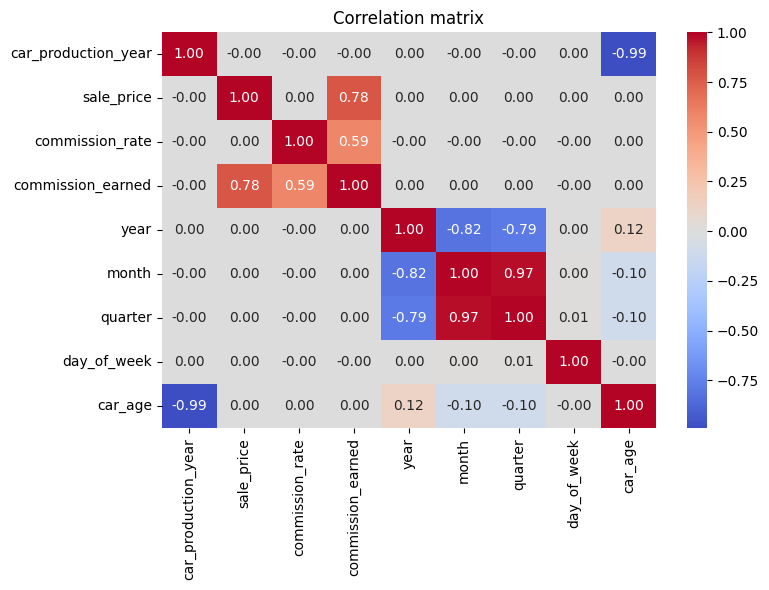

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

pandas_df = spark_df.toPandas()

# Correlation of numerical columns
numeric_pandas = pandas_df.select_dtypes(include='number')
correlation = numeric_pandas.corr()

print("Correlation with the target variable (sale_price):")
print(correlation['sale_price'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Analysis - Results

The correlation matrix reveals that none of the available numerical features have a statistically significant relationship with sale_price. All correlation values are approximately 0.000, with the exception of commission_earned (0.78), which is mathematically derived from sale_price and therefore cannot be used as a predictor.

Additionally, two pairs of highly correlated features were identified:
- car_production_year and car_age (r = -0.99): multicollinearity, expected since older production year means higher car age
- month and quarter (r = 0.97): multicollinearity, since quarter is directly derived from month

These findings suggest that sale_price was likely generated randomly in the dataset, without a real dependency on vehicle characteristics. This represents a fundamental limitation of the dataset for price prediction tasks.

Data Preparation for Machine Learning

This step prepares the dataset for the SparkML pipeline. Based on the correlation analysis, the following features were selected: numerical columns (car_production_year, commission_rate, car_age, month, quarter, day_of_week) and categorical columns (car_make, car_model). The target variable is sale_price.

Categorical columns are encoded using StringIndexer, which converts string labels into numerical indices required by SparkML. All feature columns are then combined into a single feature vector using VectorAssembler, as required by SparkML models. Rows with null values are removed before processing.

In [0]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Categorical columns
categorical_cols = ['car_make', 'car_model']

# Numerical columns used as features
numeric_cols = ['car_production_year', 'commission_rate', 'car_age', 'month', 'quarter', 'day_of_week']

# Target variable
label_col = 'sale_price'

# Removing null values
spark_df_clean = spark_df.dropna()
print(f"Number of rows: {spark_df_clean.count()}")

# StringIndexer for car_make i car_model
indexers = [
    StringIndexer(inputCol=col, outputCol=col + '_idx', handleInvalid='keep')
    for col in categorical_cols
]

# VectorAssembler
indexed_cols = [col + '_idx' for col in categorical_cols]
assembler = VectorAssembler(
    inputCols=numeric_cols + indexed_cols,
    outputCol='features',
    handleInvalid='skip'
)

Number of rows: 2500000


Data Preparation - Results

The dataset was successfully cleaned and prepared for model training. StringIndexer was applied to car_make and car_model columns, converting 
categorical string values into numerical indices. VectorAssembler combined all selected features into a single 'features' vector as required by the SparkML Linear Regression model. The prepared dataset is ready for the train/test split and model training.

Model Training - Linear Regression

A Linear Regression model was chosen as it is appropriate for predicting a continuous numerical variable (sale_price). The model is configured with Ridge regularization (elasticNetParam=0.0, regParam=0.1) to prevent overfitting.
All preprocessing steps (StringIndexer, VectorAssembler) and the model itself are combined into a single SparkML Pipeline, which ensures that the same transformations are applied consistently to both training and test data.
The dataset is split into 80% training and 20% test set using a fixed random seed for reproducibility.

In [0]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

lr = LinearRegression(
    featuresCol='features',
    labelCol=label_col,
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)

pipeline = Pipeline(stages=indexers + [assembler, lr])

train_df, test_df = spark_df_clean.randomSplit([0.8, 0.2], seed=42)
print(f"Train dataset: {train_df.count()} rows")
print(f"Test dataset:  {test_df.count()} rows")

model = pipeline.fit(train_df)
print("Model successfully trained")

Train dataset: 2000272 rows
Test dataset:  499728 rows
Model successfully trained


Model Training - Results

The dataset was successfully split into training and test sets (80/20 split). The SparkML Pipeline was fitted on the training data, applying all preprocessing steps and training the Linear Regression model in a single operation. The trained model is now ready for evaluation on the unseen test dataset.

Model Evaluation

The trained model is applied to the test dataset to generate predictions. Three regression metrics are used to evaluate model performance:

- RMSE (Root Mean Squared Error): measures the average prediction error in the same units as the target variable (price). Lower is better.
- MAE (Mean Absolute Error): measures the average absolute difference between actual and predicted values. Less sensitive to outliers than RMSE.
- R² (Coefficient of Determination): measures the proportion of variance in the target variable explained by the model. Values closer to 1.0 
indicate a better fit. Values near 0 indicate the model has no predictive power.

In [0]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test_df)

predictions.select('sale_price', 'prediction', 'car_make', 'car_model').show(10)

rmse = RegressionEvaluator(labelCol=label_col, metricName='rmse').evaluate(predictions)
mae  = RegressionEvaluator(labelCol=label_col, metricName='mae').evaluate(predictions)
r2   = RegressionEvaluator(labelCol=label_col, metricName='r2').evaluate(predictions)

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R²   : {r2:.4f}")

if r2 >= 0.75:
    print("Conclusion: The model shows satisfactory accuracy (R² >= 0.75)")
elif r2 >= 0.5:
    print("Conclusion: The model shows moderate accuracy (R² between 0.5 and 0.75)")
else:
    print("Conclusion: The model shows low accuracy (R² < 0.5)")

+----------+------------------+---------+---------+
|sale_price|        prediction| car_make|car_model|
+----------+------------------+---------+---------+
|     10095| 30024.60669291613|Chevrolet|   Altima|
|     10107|29987.434672237985|Chevrolet|   Altima|
|     10118|29996.582101032618|Chevrolet|   Altima|
|     10181|30035.854344119492|Chevrolet|   Altima|
|     10204|  30033.3451999339|Chevrolet|   Altima|
|     10227|30018.525209249245|Chevrolet|   Altima|
|     10275| 30036.97294262683|Chevrolet|   Altima|
|     10287|29990.380169431344|Chevrolet|   Altima|
|     10310|30015.065260314732|Chevrolet|   Altima|
|     10386|30000.694309312355|Chevrolet|   Altima|
+----------+------------------+---------+---------+
only showing top 10 rows
RMSE : 11,537.43
MAE  : 9,991.02
R²   : -0.0000
Conclusion: The model shows low accuracy (R² < 0.5)


Model Evaluation - Results

The model produced the following results on the test dataset:
- RMSE: 11,537.43 — the average prediction error is approximately $11,537
- MAE: 9,991.02 — the average absolute error is approximately $9,991
- R²: -0.0000 — the model explains virtually none of the variance in sale_price

The model predicts a near-constant value (~30,000) for all records regardless of input features, which is consistent with the findings from the correlation analysis — none of the available features have a meaningful relationship with sale_price. This confirms that the poor performance is not a result of model misconfiguration, but rather a fundamental limitation of the dataset where sale prices appear to have been generated independently of vehicle characteristics.

Visualization of Model Results

Two plots are generated to visually assess model performance:

- Actual vs Predicted plot: compares the true sale prices against the model's predictions. In a well-performing model, points would follow the red ideal line closely. Deviations from this line indicate prediction errors.

- Residual distribution plot: shows the distribution of residuals (actual - predicted). In a well-performing model, residuals should be normally distributed and centered around zero. A wide, flat distribution indicates the model is not capturing any underlying pattern in the data.

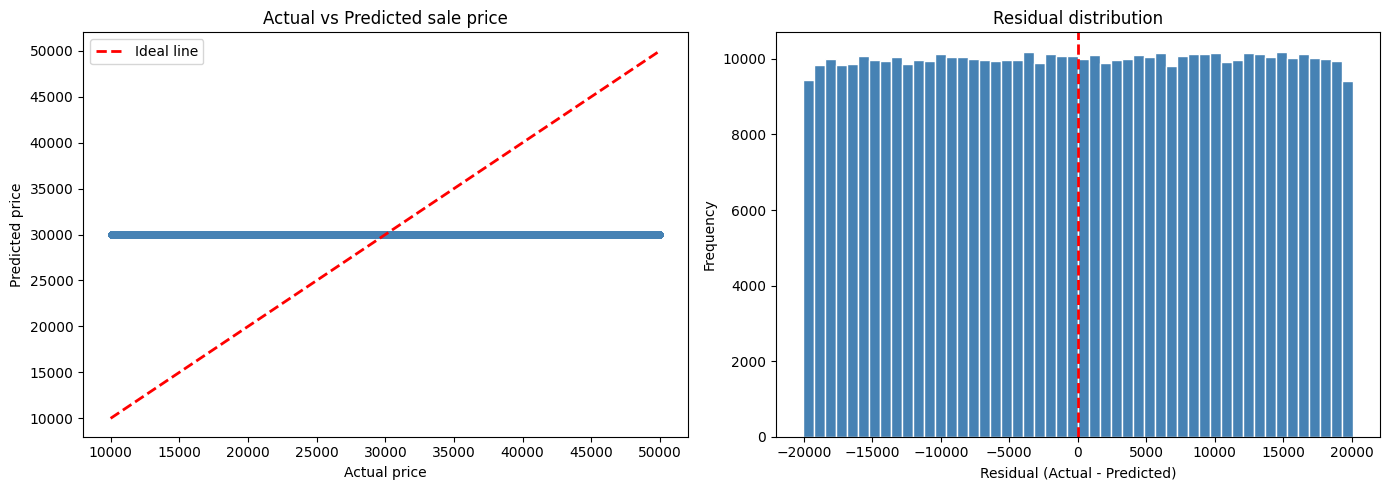

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

pred_pandas = predictions.select('sale_price', 'prediction').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 1 - Tru VS Predicted values
axes[0].scatter(pred_pandas['sale_price'], pred_pandas['prediction'], 
                alpha=0.4, color='steelblue', s=10)
min_val = min(pred_pandas['sale_price'].min(), pred_pandas['prediction'].min())
max_val = max(pred_pandas['sale_price'].max(), pred_pandas['prediction'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal line')
axes[0].set_xlabel('Actual price')
axes[0].set_ylabel('Predicted price')
axes[0].set_title('Actual vs Predicted sale price')
axes[0].legend()

# Figure 2 – Residuals distribution
reziduali = pred_pandas['sale_price'] - pred_pandas['prediction']
axes[1].hist(reziduali, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.savefig('sparkml_results.png', dpi=150, bbox_inches='tight')
plt.show()

Visualization - Results

The Actual vs Predicted plot clearly shows that the model predicts a near-constant value of approximately 30,000 for all inputs, represented as a horizontal line that does not follow the red ideal diagonal. This visually confirms the R² ≈ 0 result.

The residual distribution is wide and approximately uniform across the range of -20,000 to +20,000, with no concentration around zero. This indicates that prediction errors are essentially random and the model has not learned any meaningful pattern from the data.

Both plots are consistent with the conclusion that the available features do not contain sufficient information to predict sale_price, confirming the dataset limitation identified in the correlation analysis.